# Calidad de datos -  Empleados

1. Integración de los datos
2. Eliminar variables irrelevantes y redundantes matemática
3. Descripción estadística de los datos
4. Limpieza de datos atípicos-errores
5. Limpieza de datos nulos
6. Análisis de correlaciones para redundancias entre todas las variables
7. Análisis de correlaciones para irrelevancias respecto a la objetivo
6. Balanceo
7. Transformaciones.
8. Guardar los datos preparados


In [1]:
#Importamos librerías básicas
import pandas as pd # manipulacion dataframes
import numpy as np  # matrices y vectores
import matplotlib.pyplot as plt #gráfica



# 1. Integración de Datos










In [2]:
# Se cargan los datos de la tabla 1
datos1 = pd.read_excel("Preparacion_datos_empleados.xlsx",sheet_name='Informacion Personal')
datos1.head()

,ID,Casado,Carro,Hijos,Casa,Sexo
0,1,Sí,No,0,Alquiler,H
1,2,No,Sí,1,Alquiler,M
2,3,Sí,Sí,2,Prop,H
3,4,Sí,Sí,1,Alquiler,M
4,5,Sí,Sí,0,Prop,H


In [3]:
datos1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   ID      1080 non-null   int64 
 1   Casado  1080 non-null   object
 2   Carro   1079 non-null   object
 3   Hijos   1080 non-null   int64 
 4   Casa    1080 non-null   object
 5   Sexo    1080 non-null   object
dtypes: int64(2), object(4)
memory usage: 50.8+ KB


In [4]:
#revisamos si tenemos ID repetidos
ids = datos1['ID'].value_counts()
ids[ids > 1]

,count
ID,
48,2


In [5]:
#Sólo dejamos el id mas reciente
datos1.drop_duplicates(subset=['ID'], keep='last', inplace=True)

#el inplace=true significa que me reemplace sobre el mismo dataframe


#Verificamos de nuevo si tenemos ID repetidos
ids = datos1['ID'].value_counts()
ids[ids > 1]

,count
ID,


In [6]:
# Se cargan los datos de la tabla 2
datos2 = pd.read_excel("Preparacion_datos_empleados.xlsx",sheet_name='Informacion Laboral')
datos2.head()

,ID,Sueldo,Incapacidades,Antiguedad,Fuga
0,1,10000,7,15.0,No
1,2,20000,3,3.0,Sí
2,3,15000,5,10.0,Sí
3,4,30000,15,7.0,No
4,5,10000,1,6.0,Sí


In [7]:
datos2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1079 entries, 0 to 1078
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             1079 non-null   int64  
 1   Sueldo         1079 non-null   int64  
 2   Incapacidades  1079 non-null   int64  
 3   Antiguedad     1077 non-null   float64
 4   Fuga           1079 non-null   object 
dtypes: float64(1), int64(3), object(1)
memory usage: 42.3+ KB


In [8]:
#revisamos si tenemos ID repetidos
ids = datos2['ID'].value_counts()
ids[ids > 1]

,count
ID,


In [9]:
#Join
data = pd.merge(datos1, datos2, on='ID', how='inner')
data.head()

,ID,Casado,Carro,Hijos,Casa,Sexo,Sueldo,Incapacidades,Antiguedad,Fuga
0,1,Sí,No,0,Alquiler,H,10000,7,15.0,No
1,2,No,Sí,1,Alquiler,M,20000,3,3.0,Sí
2,3,Sí,Sí,2,Prop,H,15000,5,10.0,Sí
3,4,Sí,Sí,1,Alquiler,M,30000,15,7.0,No
4,5,Sí,Sí,0,Prop,H,10000,1,6.0,Sí


In [10]:
#se revisan los tipos de datos
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1079 entries, 0 to 1078
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             1079 non-null   int64  
 1   Casado         1079 non-null   object 
 2   Carro          1078 non-null   object 
 3   Hijos          1079 non-null   int64  
 4   Casa           1079 non-null   object 
 5   Sexo           1079 non-null   object 
 6   Sueldo         1079 non-null   int64  
 7   Incapacidades  1079 non-null   int64  
 8   Antiguedad     1077 non-null   float64
 9   Fuga           1079 non-null   object 
dtypes: float64(1), int64(4), object(5)
memory usage: 84.4+ KB


In [11]:
#corrección del tipo de datos object a categorías
data['Casado']=data['Casado'].astype('category')
data['Carro']=data['Carro'].astype('category')
data['Casa']=data['Casa'].astype('category')
data['Sexo']=data['Sexo'].astype('category')
data['Fuga']=data['Fuga'].astype('category')

data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1079 entries, 0 to 1078
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   ID             1079 non-null   int64   
 1   Casado         1079 non-null   category
 2   Carro          1078 non-null   category
 3   Hijos          1079 non-null   int64   
 4   Casa           1079 non-null   category
 5   Sexo           1079 non-null   category
 6   Sueldo         1079 non-null   int64   
 7   Incapacidades  1079 non-null   int64   
 8   Antiguedad     1077 non-null   float64 
 9   Fuga           1079 non-null   category
dtypes: category(5), float64(1), int64(4)
memory usage: 48.2 KB


# 2. Eliminar variables irrelevantes y redundantes
* Irrelevantes: cedulas, ids, nombres, telefonos, direcciones, códigos.
* Redundantes: validación por fórmula matemática que están repetidas

In [12]:
# Variables irrelevantes para el proceso de minería
data = data.drop('ID',axis=1) #Eliminamos el ID por ser irrelevante, axis=1 indica que es una columna
data.head()

,Casado,Carro,Hijos,Casa,Sexo,Sueldo,Incapacidades,Antiguedad,Fuga
0,Sí,No,0,Alquiler,H,10000,7,15.0,No
1,No,Sí,1,Alquiler,M,20000,3,3.0,Sí
2,Sí,Sí,2,Prop,H,15000,5,10.0,Sí
3,Sí,Sí,1,Alquiler,M,30000,15,7.0,No
4,Sí,Sí,0,Prop,H,10000,1,6.0,Sí


# 3. Descripción estadística

**Variables numéricas**

In [13]:
#conocemos un poco los datos numéricos
data.describe()

,Hijos,Sueldo,Incapacidades,Antiguedad
count,1079.000000,1079.000000,1079.000000,1077.000000
mean,0.732159,21058.387396,5.625579,8.186630
std,0.997954,11898.898532,13.839617,5.252145
min,0.000000,8000.000000,0.000000,1.000000
25%,0.000000,10000.000000,1.000000,5.000000
50%,0.000000,20000.000000,3.000000,7.000000
75%,2.000000,30000.000000,7.000000,12.000000
max,3.000000,50000.000000,400.000000,20.000000


array([[<Axes: title={'center': 'Hijos'}>,
        <Axes: title={'center': 'Sueldo'}>],
       [<Axes: title={'center': 'Incapacidades'}>,
        <Axes: title={'center': 'Antiguedad'}>]], dtype=object)

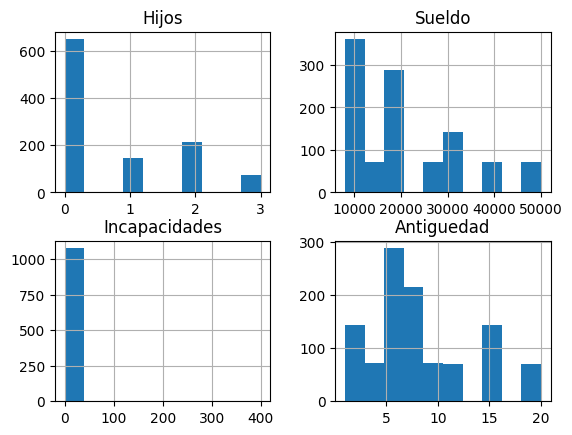

In [14]:
#sacar todos los histogramas juntos
data.hist()

<Axes: >

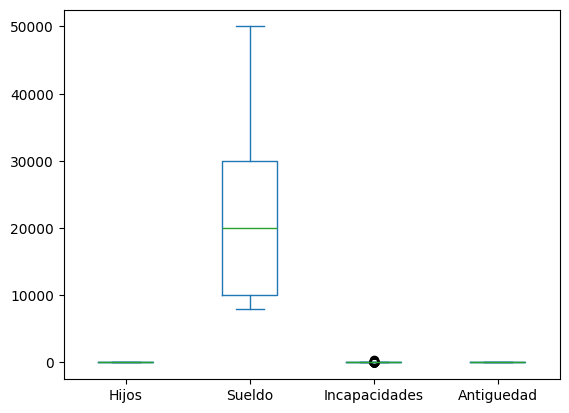

In [15]:
data.plot.box()

<Axes: >

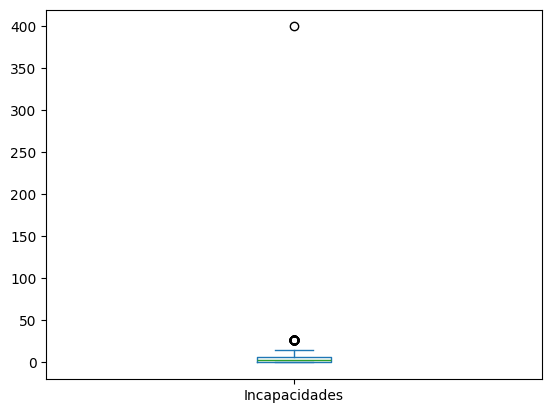

In [16]:
data['Incapacidades'].plot.box()

**Variables categóricas** (value_counts())

<Axes: xlabel='Casado'>

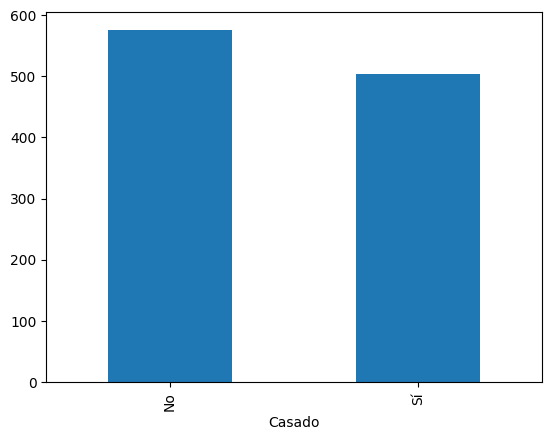

In [17]:
#conocemos las variables categóricas: bar, barh, pie

data['Casado'].value_counts().plot(kind='bar')

<Axes: xlabel='Sexo'>

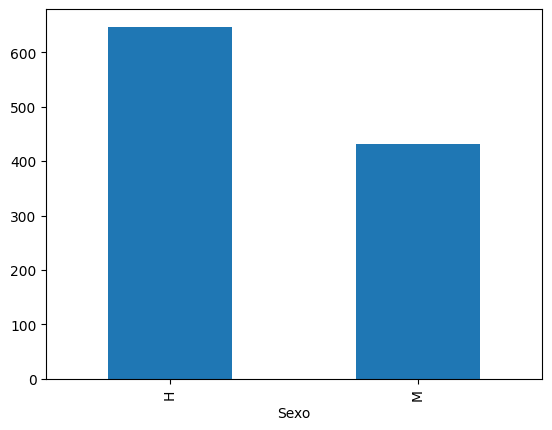

In [18]:
#resto de gráficas de barras
data['Sexo'].value_counts().plot(kind='bar')


<Axes: xlabel='Carro'>

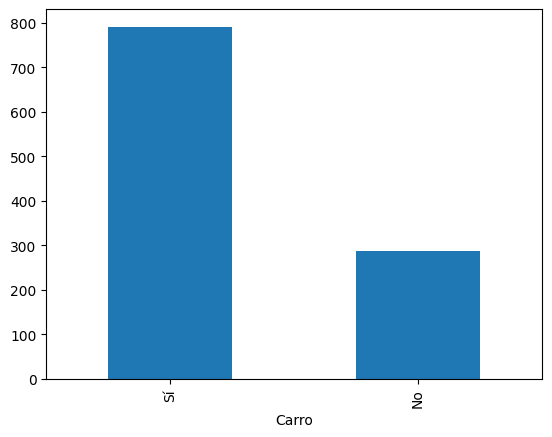

In [19]:
#resto de gráficas de barras
data['Carro'].value_counts().plot(kind='bar')

<Axes: xlabel='Casa'>

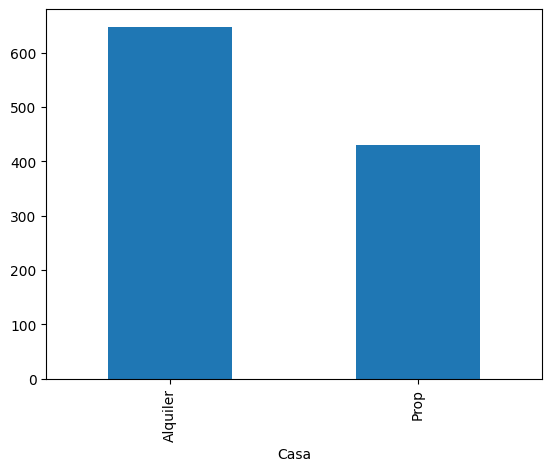

In [20]:
#resto de gráficas de barras
data['Casa'].value_counts().plot(kind='bar')

<Axes: xlabel='Fuga'>

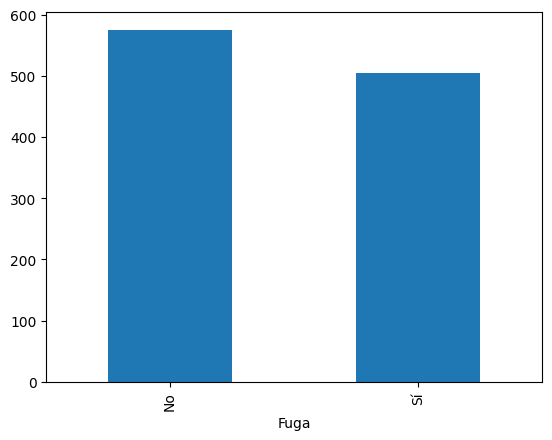

In [21]:
#resto de gráficas de barras
data['Fuga'].value_counts().plot(kind='bar')

**Gráficas de las relaciones entre variables**

array([[<Axes: xlabel='Hijos', ylabel='Hijos'>,
        <Axes: xlabel='Sueldo', ylabel='Hijos'>,
        <Axes: xlabel='Incapacidades', ylabel='Hijos'>,
        <Axes: xlabel='Antiguedad', ylabel='Hijos'>],
       [<Axes: xlabel='Hijos', ylabel='Sueldo'>,
        <Axes: xlabel='Sueldo', ylabel='Sueldo'>,
        <Axes: xlabel='Incapacidades', ylabel='Sueldo'>,
        <Axes: xlabel='Antiguedad', ylabel='Sueldo'>],
       [<Axes: xlabel='Hijos', ylabel='Incapacidades'>,
        <Axes: xlabel='Sueldo', ylabel='Incapacidades'>,
        <Axes: xlabel='Incapacidades', ylabel='Incapacidades'>,
        <Axes: xlabel='Antiguedad', ylabel='Incapacidades'>],
       [<Axes: xlabel='Hijos', ylabel='Antiguedad'>,
        <Axes: xlabel='Sueldo', ylabel='Antiguedad'>,
        <Axes: xlabel='Incapacidades', ylabel='Antiguedad'>,
        <Axes: xlabel='Antiguedad', ylabel='Antiguedad'>]], dtype=object)

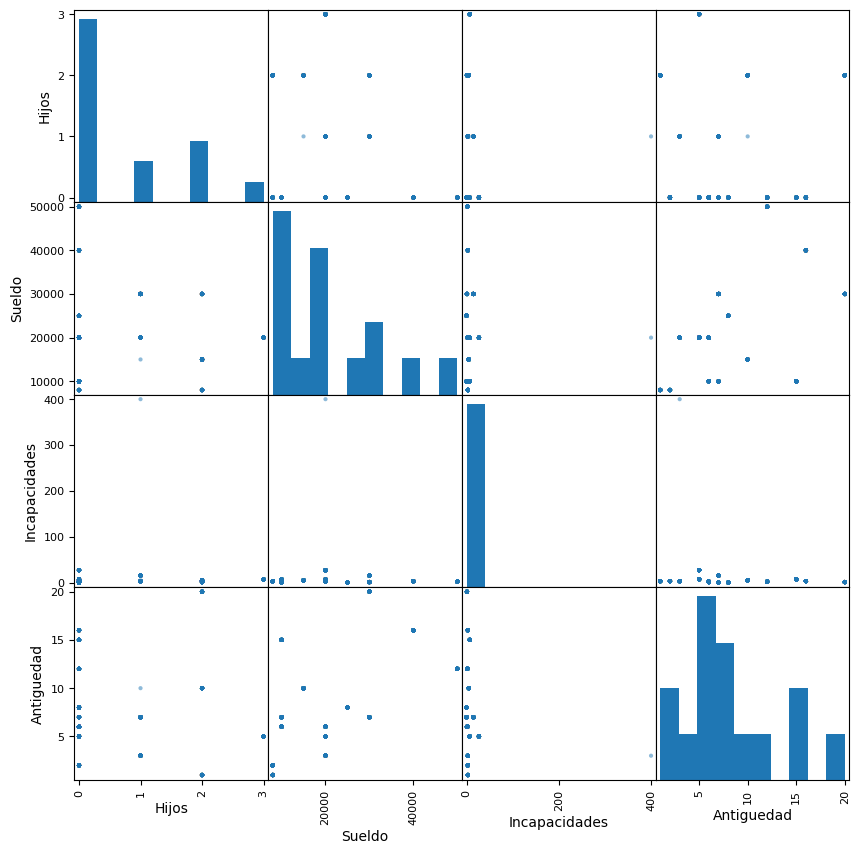

In [22]:
# Gráficas para identificar relaciones entre las variables
pd.plotting.scatter_matrix(data, figsize=(10,10))

**si alguna de esas graficas tiene linea recta perfecta, significa que podrían ser redundantes**

**Perfilado de datos**

herramienta que automaticamente me grafica todas las variables

In [23]:
!pip install ydata-profiling

from ydata_profiling import ProfileReport

profile_data=ProfileReport(data, minimal=True) # minimal=True
profile_data

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 57.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.4 MB/s eta 0:00:00


/tmp/ipykernel_1562/3548343713.py:3: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 9/9 [00:00<00:00, 93.77it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [24]:
#Guardamos en html el perfilado de datos
profile_data.to_file(output_file="output.html")

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

# **Dimensiones de la Calidad de Datos**

**Completitud:** ¿Está toda la información disponible? ¿Hay datos faltantes o ausentes?

**Exactitud:**¿La información es correcta y libre de error?

**Conformidad:** ¿Los valores de los datos están conformes con los formatos esperados? Ejemplo: Una fecha en formato AAAA/MM/DD cuando debería ser DD/MM/AAAA.

**Oportunidad:** ¿La información llega cuando se necesita?

**Duplicidad:** ¿Existen múltiples instancias, innecesarias de los mismos objetos de datos en el conjunto de datos?

**Integridad:** ¿Faltan datos relacionados importantes? ¿Es clara la conectividad y las relaciones con otros datos?

# **Diagnóstico de las dimensiones según el perfilado:**
* Completitud:  
- hay (1) missing en carro , y (2) missing en antiguedad
* Exactitud: errores en incapacidades
- ya que hay un rango de mín. 0 , median	3, Maximum	400
* Conformidad: no hay información de fechas
* Oportunidad: no se puedo verificar
* Duplicidad: id repetidos
* Integridad: se podría agregar una variable de área del empleado, para conectar con el sueldo

# 4. Limpieza de datos atípicos-errores
- Sólo se limpian errores

In [25]:
data.describe()

,Hijos,Sueldo,Incapacidades,Antiguedad
count,1079.000000,1079.000000,1079.000000,1077.000000
mean,0.732159,21058.387396,5.625579,8.186630
std,0.997954,11898.898532,13.839617,5.252145
min,0.000000,8000.000000,0.000000,1.000000
25%,0.000000,10000.000000,1.000000,5.000000
50%,0.000000,20000.000000,3.000000,7.000000
75%,2.000000,30000.000000,7.000000,12.000000
max,3.000000,50000.000000,400.000000,20.000000


In [26]:
#Se asigna valor nulo a los atípicos

data.loc[data["Incapacidades"]>365, "Incapacidades"]=np.nan #data.loc[filas, col]
data.describe()

,Hijos,Sueldo,Incapacidades,Antiguedad
count,1079.000000,1079.000000,1078.000000,1077.000000
mean,0.732159,21058.387396,5.259740,8.186630
std,0.997954,11898.898532,6.867851,5.252145
min,0.000000,8000.000000,0.000000,1.000000
25%,0.000000,10000.000000,1.000000,5.000000
50%,0.000000,20000.000000,3.000000,7.000000
75%,2.000000,30000.000000,7.000000,12.000000
max,3.000000,50000.000000,27.000000,20.000000


#**5. Limpieza de datos nulos: Imputación**

---
Estrategia:
* Eliminar registros con mas de 15% de nulos
* Eliminar columnas con mas de 15%-20% de nulos
* Imputar por media, moda, mediana, vecinos cercanos. No se puede imputar más allá del 15% de los datos.
* Para casos especiales se crea modelo predictivo

In [27]:
#Limpieza de datos nulos: Imputación por la media y moda
from sklearn.impute import SimpleImputer

#Imputacion de variables numéricas: media, mediana
var_numericas = ['Incapacidades','Antiguedad']
ImpNumeros = SimpleImputer(missing_values=np.nan, strategy='mean')
data[var_numericas] = ImpNumeros.fit_transform(data[var_numericas])

#Imputacion de variables categóricas: moda
var_categoricas = ['Carro']
ImpCategorias = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
data[var_categoricas] = ImpCategorias.fit_transform(data[var_categoricas])

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1079 entries, 0 to 1078
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Casado         1079 non-null   category
 1   Carro          1079 non-null   object  
 2   Hijos          1079 non-null   int64   
 3   Casa           1079 non-null   category
 4   Sexo           1079 non-null   category
 5   Sueldo         1079 non-null   int64   
 6   Incapacidades  1079 non-null   float64 
 7   Antiguedad     1079 non-null   float64 
 8   Fuga           1079 non-null   category
dtypes: category(4), float64(2), int64(2), object(1)
memory usage: 47.0+ KB


In [28]:
#Valores de la imputación
print(ImpNumeros.statistics_) #['Incapacidades','Antiguedad']
print(ImpCategorias.statistics_) # Carro

[5.25974026 8.18662953]
['Sí']


# 6. Correlaciones para redundancias

In [29]:
#Todas las variables deben ser númericas para calcular las correlacciones, se crean dummies para las variables categóricas

data_num = pd.get_dummies(data, drop_first=True, dtype=int)
data_num.head()

,Hijos,Sueldo,Incapacidades,Antiguedad,Casado_Sí,Carro_Sí,Casa_Prop,Sexo_M,Fuga_Sí
0,0,10000,7.0,15.0,1,0,0,0,0
1,1,20000,3.0,3.0,0,1,0,1,1
2,2,15000,5.0,10.0,1,1,1,0,1
3,1,30000,15.0,7.0,1,1,0,1,0
4,0,10000,1.0,6.0,1,1,1,0,1


**Correlaciones para redundacia= mayores |0.8|**

In [30]:
#correlaciones
correlaciones=data_num.corr()
correlaciones

,Hijos,Sueldo,Incapacidades,Antiguedad,Casado_Sí,Carro_Sí,Casa_Prop,Sexo_M,Fuga_Sí
Hijos,1.000000,-0.088208,-0.009335,-0.043236,0.651359,0.441850,0.626839,-0.326711,-0.286804
Sueldo,-0.088208,1.000000,0.014302,0.524112,-0.275918,-0.262990,-0.266518,0.611942,-0.083314
Incapacidades,-0.009335,0.014302,1.000000,-0.164894,0.039897,-0.330893,-0.249287,0.403594,-0.444169
Antiguedad,-0.043236,0.524112,-0.164894,1.000000,0.166948,-0.207404,-0.034004,-0.003403,-0.033314
Casado_Sí,0.651359,-0.275918,0.039897,0.166948,1.000000,0.259807,0.599620,-0.490593,-0.338676
Carro_Sí,0.441850,-0.262990,-0.330893,-0.207404,0.259807,1.000000,0.490941,-0.124544,0.265097
Casa_Prop,0.626839,-0.266518,-0.249287,-0.034004,0.599620,0.490941,1.000000,-0.388352,0.051885
Sexo_M,-0.326711,0.611942,0.403594,-0.003403,-0.490593,-0.124544,-0.388352,1.000000,0.057676
Fuga_Sí,-0.286804,-0.083314,-0.444169,-0.033314,-0.338676,0.265097,0.051885,0.057676,1.000000


In [ ]:
#Detección de redundantes = se buscan correlaciones peligrosamente altas (0.8-1.0)

#data = data.drop('redundante',axis=1)
#data.head()

# 7. Correlaciones para irrelevancia con la variable objetivo

Se buscan correlaciones con la variable objetivo muy bajas (0.0-0.05 ) ->ultima fila

In [31]:
#Correlaciones con la variable de objetivo
cor_variable_obj=correlaciones.loc['Fuga_Sí']
cor_variable_obj

,Fuga_Sí
Hijos,-0.286804
Sueldo,-0.083314
Incapacidades,-0.444169
Antiguedad,-0.033314
Casado_Sí,-0.338676
Carro_Sí,0.265097
Casa_Prop,0.051885
Sexo_M,0.057676
Fuga_Sí,1.000000


<BarContainer object of 9 artists>

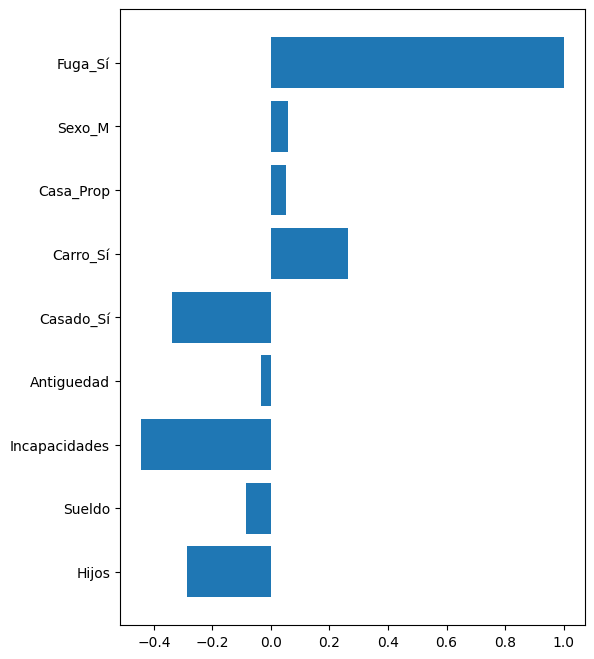

In [32]:
plt.figure(figsize=(6, 8))
plt.barh(y = data_num.columns, width=cor_variable_obj)

Mas incapacidad, mas fuga.
Menos importante incapacidad

In [33]:
#Detección de irrelevantes = se buscan correlaciones con la variable objetivo muy bajas (0.0-0.05 ) ->ultima fila

data = data.drop('Antiguedad',axis=1)
data.head()

,Casado,Carro,Hijos,Casa,Sexo,Sueldo,Incapacidades,Fuga
0,Sí,No,0,Alquiler,H,10000,7.0,No
1,No,Sí,1,Alquiler,M,20000,3.0,Sí
2,Sí,Sí,2,Prop,H,15000,5.0,Sí
3,Sí,Sí,1,Alquiler,M,30000,15.0,No
4,Sí,Sí,0,Prop,H,10000,1.0,Sí


# 8. Balanceo de la variable objetivo (Clasificación)

<Axes: xlabel='Fuga'>

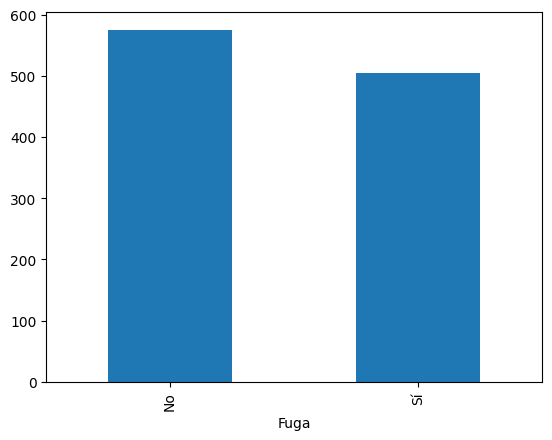

In [34]:
#Variable objetivo
data["Fuga"].value_counts().plot(kind="bar")

No hay problema de balanceo, pero para poner en práctica SMOTE

In [35]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1079 entries, 0 to 1078
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Casado         1079 non-null   category
 1   Carro          1079 non-null   object  
 2   Hijos          1079 non-null   int64   
 3   Casa           1079 non-null   category
 4   Sexo           1079 non-null   category
 5   Sueldo         1079 non-null   int64   
 6   Incapacidades  1079 non-null   float64 
 7   Fuga           1079 non-null   category
dtypes: category(4), float64(1), int64(2), object(1)
memory usage: 38.5+ KB


In [36]:
from imblearn.over_sampling import SMOTE, SMOTENC

#sm = SMOTE( k_neighbors=2) para variables predictoras numéricas
#sm = SMOTENC(categorical_features=[], k_neighbors=2) para variables predictoras categóricas

sm = SMOTENC(categorical_features=[0,1,3,4], k_neighbors=2) #se indican las variables predictoras categoricas
X= data.drop('Fuga', axis=1) #Predictoras
Y= data['Fuga'] #Objetivo
X_bal, Y_bal = sm.fit_resample(X,Y) #X= variables predictoras Y=variable objetivo

<Axes: xlabel='Fuga'>

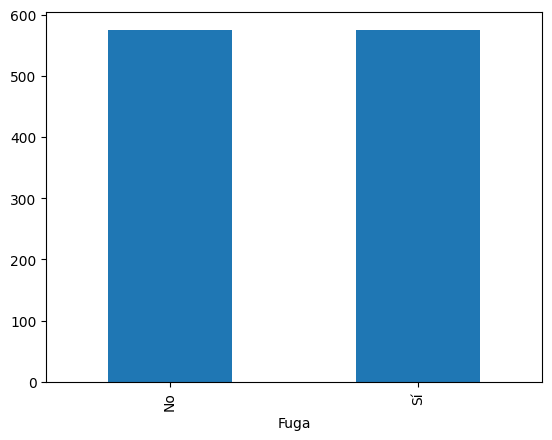

In [37]:
# Creamos un dataframe con los resultados
data  = pd.DataFrame(columns=X.columns.values, data=X_bal)
data['Fuga']=Y_bal
data['Fuga'].value_counts().plot(kind='bar')

# 9. Transformaciones
- Si el metodo de ML es para variables categóricas (arboles, bayes, apriori)->Discretización
- Si el mertodo de ML es para variables numéricas(RN, regresiones, SVM, Knn, Kmeans)->Normalizar, dummies a las predictoras y labelencoder a la objetivo

**`9.1 Discretización`**: Transformación de número a categoría

In [40]:
data_cat = data.copy()


<Axes: xlabel='Incapacidades'>

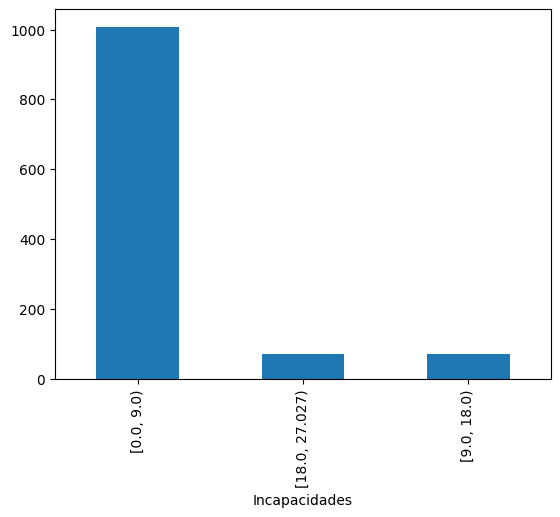

In [41]:
#Cut
data_cat['Incapacidades'] = pd.cut(data_cat['Incapacidades'] , bins=3, right = False)
data_cat['Incapacidades'].value_counts().plot(kind='bar')

<Axes: xlabel='Sueldo'>

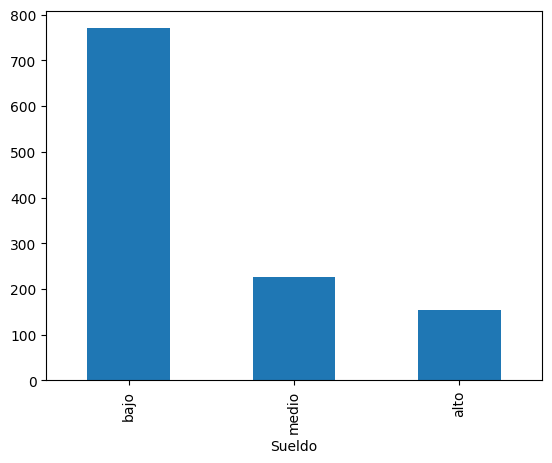

In [42]:
#Discretizar indicando los nombres de las categorías
data_cat['Sueldo'] = pd.cut(data_cat['Sueldo'] , bins=3, labels=['bajo','medio','alto'])
data_cat['Sueldo'].value_counts().plot(kind='bar')

<Axes: xlabel='Hijos'>

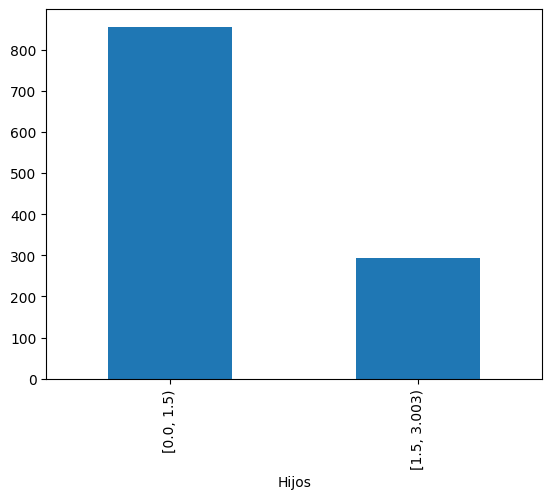

In [43]:
#Discretizar indicando los nombres de las categorías
data_cat['Hijos'] = pd.cut(data_cat['Hijos'] , bins=2, right=False)
data_cat['Hijos'].value_counts().plot(kind='bar')

**`9.2 Normalización de variables numéricas`**

MINMAXSCALER: rANGO DE CERO A UNO


In [44]:
#Normalización: Sólo para variables numéricas (no dummies)
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler()
data[[ 'Hijos', 'Sueldo','Incapacidades']] = min_max_scaler.fit_transform(data[['Hijos', 'Sueldo','Incapacidades']])
data.head()

,Casado,Carro,Hijos,Casa,Sexo,Sueldo,Incapacidades,Fuga
0,Sí,No,0.000000,Alquiler,H,0.047619,0.259259,No
1,No,Sí,0.333333,Alquiler,M,0.285714,0.111111,Sí
2,Sí,Sí,0.666667,Prop,H,0.166667,0.185185,Sí
3,Sí,Sí,0.333333,Alquiler,M,0.523810,0.555556,No
4,Sí,Sí,0.000000,Prop,H,0.047619,0.037037,Sí


**`9.3 Dummies:`** Transformación de categorías a números

In [45]:
#Creación de dummies a las variables categóricas



#Variables categóricas con 2 categorías -> Borramos una dummy

data = pd.get_dummies(data, columns=['Casado','Carro','Casa','Sexo'], drop_first=True, dtype=int)



#Variables categóricas con más de 2 categorías -> No borramos

#data = pd.get_dummies(data, columns=['Cat'], drop_first=False)

data.head()



,Hijos,Sueldo,Incapacidades,Fuga,Casado_Sí,Carro_Sí,Casa_Prop,Sexo_M
0,0.000000,0.047619,0.259259,No,1,0,0,0
1,0.333333,0.285714,0.111111,Sí,0,1,0,1
2,0.666667,0.166667,0.185185,Sí,1,1,1,0
3,0.333333,0.523810,0.555556,No,1,1,0,1
4,0.000000,0.047619,0.037037,Sí,1,1,1,0


**`9.4 Label Encoder:`** sólo para la variable objetivo

In [46]:
# Codificar la variable objetivo cuando es categórica

from sklearn.preprocessing import LabelEncoder

labelencoder = LabelEncoder()
data["Fuga"] = labelencoder.fit_transform(data["Fuga"])
data.head()

,Hijos,Sueldo,Incapacidades,Fuga,Casado_Sí,Carro_Sí,Casa_Prop,Sexo_M
0,0.000000,0.047619,0.259259,0,1,0,0,0
1,0.333333,0.285714,0.111111,1,0,1,0,1
2,0.666667,0.166667,0.185185,1,1,1,1,0
3,0.333333,0.523810,0.555556,0,1,1,0,1
4,0.000000,0.047619,0.037037,1,1,1,1,0


# 10. Guardar los datos preparados

In [47]:
data_cat.to_excel("./datos_categoricos.xlsx")

In [48]:
data.to_excel('./datos_normalizados.xlsx')

# **FIN**